In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ticks = ["XLE", # ~25 largest US energy stocks (most liquid)
         "FENY", # Broad US energy (large, mid, small cap)
         "VDE", # Very similar to FENY
         "IYE", # US energy, large and mid cap
         "RYE", # Equal weight S&P500 energy stocks (mid cap heavy, higher volatility)
         "IXC", # Global energy exposure
         "XOP", # Equal weight E&P stocks, pure oil price exposure (small, mid cap heavy, high volatility)
         "PXE", # Similar to XOP, but factor-based weighting (momentum & value)
         "OIH", # US oil services, high cap
         "XES", # Similar to OIH (small, mid cap heavy)
]
start = "2017-01-01"
end = "2023-01-01"
interval = "1wk" # or "1d"

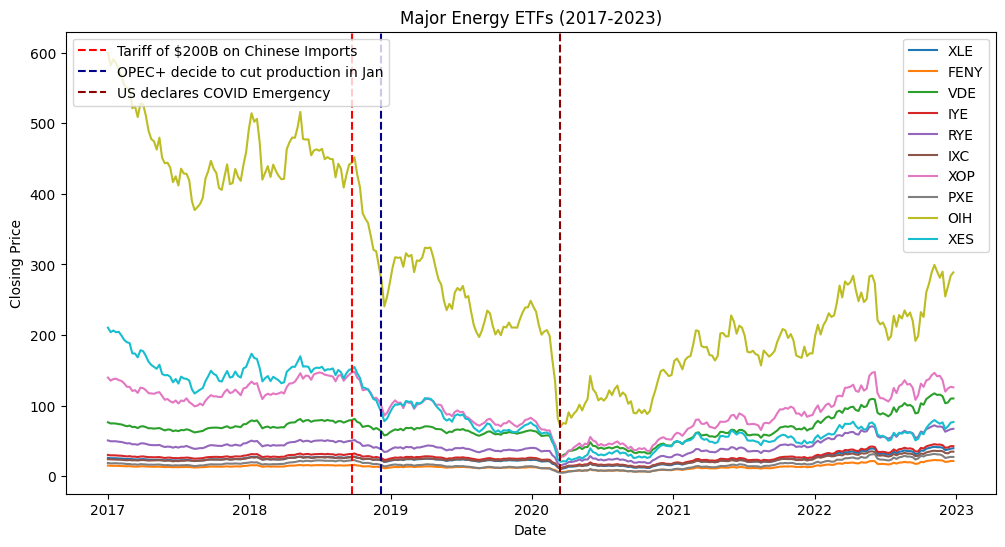

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Graph ETF closing prices
for tick in ticks:
    df = pd.read_csv(f"data/energy/{tick}_{start}_{end}_{interval}.csv", parse_dates=["Date"])
    ax.plot(df["Date"], df["Close"], label=tick)

legend = ax.legend(loc="upper right")

# Graph vertical lines for major events
event_dates = [
    (pd.to_datetime("2018-09-24"), "Tariff of $200B on Chinese Imports", "red"),
    (pd.to_datetime("2018-12-07"), "OPEC+ decide to cut production in Jan", "darkblue"),
    (pd.to_datetime("2020-03-13"), "US declares COVID Emergency", "darkred"),
]

vline_handles = []
for date, label, color in event_dates:
    line = ax.axvline(x=date, linestyle="--", color=color)
    vline_handles.append(line)

ax.legend(vline_handles, [label for _, label, _ in event_dates], loc="upper left")
ax.add_artist(legend) # Keep both legends

plt.title("Major Energy ETFs (2017-2023)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()